# Parte 1 — Baseline por quadro

O detector entrega, a cada quadro, um conjunto de caixas sem relação nenhuma com o conjunto do quadro seguinte. Esta parte mede o que acontece quando a identidade é decidida **só** pela sobreposição entre quadros vizinhos — sem memória, sem modelo de movimento, sem aparência. É a referência contra a qual a Parte 2 (memória recorrente) vai ser comparada.

O que está aqui, na ordem do enunciado:

1. **Dados e split por sequência** — as 7 sequências com ground truth do MOT17, os eixos de dificuldade medidos no próprio GT e o split treino/validação justificado.
2. **Detecções, sem treinar detector** — as duas fontes: as **detecções públicas** (DPM, FRCNN, SDP; escolhemos uma como fonte padrão do resto do PA) e um **Faster R-CNN pré-treinado do torchvision** (classe *person* do COCO), com o NMS final substituído pelo nosso.
3. **Associação ingênua** — IoU entre a caixa da track (a última observada) e as detecções do quadro, matching guloso ou Hungarian, limiar fixo, id novo quando nada casa, track morta após `max_age` quadros sem observação. A regra está documentada em `src/nn/tracking.py` e na seção 4; a grade de hiperparâmetros mostra quanto os números dependem dela.
4. **Avaliação como trajetórias** — IDF1, ID switches, fragmentações e erro de contagem de identidades, com as métricas de `src/nn/metrics.py` (mais MOTA, opcional).
5. **Quantificar o fracasso** — o gráfico do descolamento em dois painéis sobre as mesmas sequências, ordenadas por um eixo de dificuldade, e um diagnóstico de onde a identidade se perde.

**Protocolo.** Toda escolha (detector público, limiar de score, regra de associação, NMS do torchvision) é feita **só nas sequências de treino**; as de validação aparecem nas tabelas, mas nunca participaram de uma decisão.

**Avaliação.** Pré-processamento oficial do MOTChallenge em todas as métricas (`src/dataset/mot17.py::remove_distractor_matches`): o GT avaliado são os pedestres com `conf = 1`; previsões que caem sobre **distratores** (pessoa em veículo, pessoa estática, reflexo — classes 2, 7, 8, 12) são removidas antes de contar FP. Um par (previsão, GT) conta como a mesma pessoa num quadro se IoU ≥ 0,5.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import spearmanr

from src.dataset.mot17 import (
    load_sequences, SEQUENCES, SPLIT, sequence_statistics, occlusion_durations,
    consecutive_iou, remove_distractor_matches, evaluate_sequence, detections_to_mot,
)
from src.nn.boxes import FRAME, ID, X1, Y1, X2, Y2, CONF
from src.nn.metrics import (
    mean_average_precision, detection_counts, reacquisition_events, keep_rate_by_gap,
)
from src.nn.tracking import track_sequence
from src.nn.detector import run_on_sequence, apply_nms, read_time, cache_path, DEFAULT_ARCH
from src.plot.plot import plot_decoupling, plot_keep_rate, plot_tracks_timeline, show_sequence_frames

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = "../data"
CACHE_DIR = os.path.join(DATA_ROOT, "detections")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

TRAIN, VAL = SPLIT["train"], SPLIT["val"]

def split_of(name):
    return "val" if name in VAL else "treino"


COUNT_COLS = {"IDSW", "FRAG", "n_gt_ids", "n_pred_ids", "count_error", "IDTP", "IDFP", "IDFN", "TP", "FP", "FN"}


def show_table(df, cols=None):
    # contadores sem casas decimais (exceto em linhas de média), o resto com 3
    out = df if cols is None else df[cols]
    out = out.copy()
    for c in out.columns:
        if c in COUNT_COLS:
            out[c] = [("" if pd.isna(v) else f"{v:.0f}" if float(v).is_integer() else f"{v:.1f}") for v in out[c]]
    print(out.to_string(float_format=lambda x: f"{x:.3f}"))

## 1. Os dados e o split por sequência

As 7 sequências de treino do MOT17 são as únicas com ground truth público (as de teste só têm detecções). As anotações são as mesmas nas três pastas `-DPM`, `-FRCNN` e `-SDP`; só muda `det/det.txt`. Os quadros vêm do `MOT17Det.zip` (as mesmas imagens, uma vez por sequência).

In [2]:
seqs = load_sequences(SEQUENCES, root=DATA_ROOT)

overview = pd.DataFrame([{
    "sequência": s.name,
    "split": split_of(s.name),
    "câmera": s.meta["camera"],
    "ponto de vista": s.meta["viewpoint"],
    "cena": s.meta["scene"],
    "fps": s.fps,
    "resolução": f"{s.width}x{s.height}",
    "quadros": s.n_frames,
    "duração (s)": round(s.n_frames / s.fps, 1),
    "ids": len(np.unique(s.gt[:, ID])),
    "caixas GT": len(s.gt),
    "quadros disponíveis": s.has_images,
} for s in seqs.values()]).set_index("sequência")

print(overview.to_string())
print(f"\ntreino: {TRAIN}\nval:    {VAL}")

            split  câmera   ponto de vista                                cena  fps  resolução  quadros  duração (s)  ids  caixas GT  quadros disponíveis
sequência                                                                                                                                                
MOT17-02   treino  parada  nivel dos olhos                          praca, dia   30  1920x1080      600         20.0   62      18581                 True
MOT17-04   treino  parada          elevado             rua de pedestres, noite   30  1920x1080     1050         35.0   83      47557                 True
MOT17-05   treino   movel  nivel dos olhos               rua, plataforma movel   14    640x480      837         59.8  133       6917                 True
MOT17-09      val  parada            baixo                    rua de pedestres   30  1920x1080      525         17.5   26       5325                 True
MOT17-10      val   movel  nivel dos olhos                          rua, noi

**Split.** Por sequência, nunca por quadro: o quadro $t$ e o $t+1$ de uma mesma sequência são quase idênticos, e separar quadros ao acaso avaliaria o modelo temporal em cima do que ele já viu. A validação é **MOT17-09 + MOT17-10**, nunca vistas por nenhuma escolha deste PA:

- **câmera parada vs. móvel** — a validação tem uma de cada (09 parada, 10 em movimento); o treino tem 2 paradas (02, 04) e 3 móveis (05, 11, 13). O modelo de movimento da Parte 2 precisa ser avaliado nos dois regimes, porque o que "movimento" significa muda: com câmera parada é só o pedestre; com câmera móvel é o pedestre mais o ego-movimento;
- **densidade** — a validação fica no meio da faixa (10 e 20 pessoas/quadro); os dois extremos, 04 (45/quadro) e 05 (8/quadro), ficam no treino, para o modelo ver a faixa inteira;
- **ponto de vista e condição** — 09 é de ângulo baixo, 10 é noturna;
- **o que precisa estar no treino** — a única sequência a 14 fps e 640×480 (05) e a câmera de ônibus (13, o movimento aparente mais rápido): sem elas o modelo de movimento nunca veria um $\Delta t$ ou uma dinâmica diferentes.

## 2. Eixos de dificuldade, medidos no ground truth

O enunciado pede que as sequências sejam ordenadas por um eixo de dificuldade. Antes de rodar qualquer rastreador, medimos os candidatos no GT (`src/dataset/mot17.py::sequence_statistics`):

- **densidade** — pedestres por quadro;
- **oclusão** — fração das caixas com visibilidade < 0,5, e a duração das oclusões: por identidade, sequências de quadros consecutivos com visibilidade < 0,25 em que a pessoa some **e volta** (as que exigem memória). Em segundos, porque as sequências têm fps diferentes;
- **movimento aparente** — o IoU entre a caixa da mesma pessoa em quadros consecutivos (`consecutive_iou`). Junta movimento do pedestre, movimento da câmera, tamanho da caixa e taxa de quadros numa unidade só — e é **exatamente** a quantidade que a associação ingênua usa. Se esse IoU cai abaixo do limiar de associação, nem um detector perfeito salva a identidade.

In [3]:
stats = pd.DataFrame([sequence_statistics(s) for s in seqs.values()]).set_index("sequence")
stats["apparent_motion"] = 1.0 - stats["consec_iou"]
stats["split"] = [split_of(n) for n in stats.index]

cols = ["split", "camera", "fps", "density", "frac_occluded", "n_occlusions", "occ_mean_frames",
        "occ_mean_s", "occ_p90_s", "consec_iou", "frac_low_iou", "apparent_motion", "box_height"]
print(stats[cols].to_string())

           split  camera  fps  density  frac_occluded  n_occlusions  occ_mean_frames  occ_mean_s  occ_p90_s  consec_iou  frac_low_iou  apparent_motion  box_height
sequence                                                                                                                                                          
MOT17-02  treino  parada   30   30.968          0.608           117           47.709       1.590      3.720       0.967         0.000            0.033       102.0
MOT17-04  treino  parada   30   45.292          0.392            90           30.656       1.022      3.210       0.975         0.000            0.025       171.0
MOT17-05  treino   movel   14    8.264          0.470           111            9.414       0.672      1.214       0.856         0.027            0.144       189.0
MOT17-09     val  parada   30   10.143          0.408            41           20.976       0.699      2.067       0.921         0.000            0.079       285.0
MOT17-10     val   mov

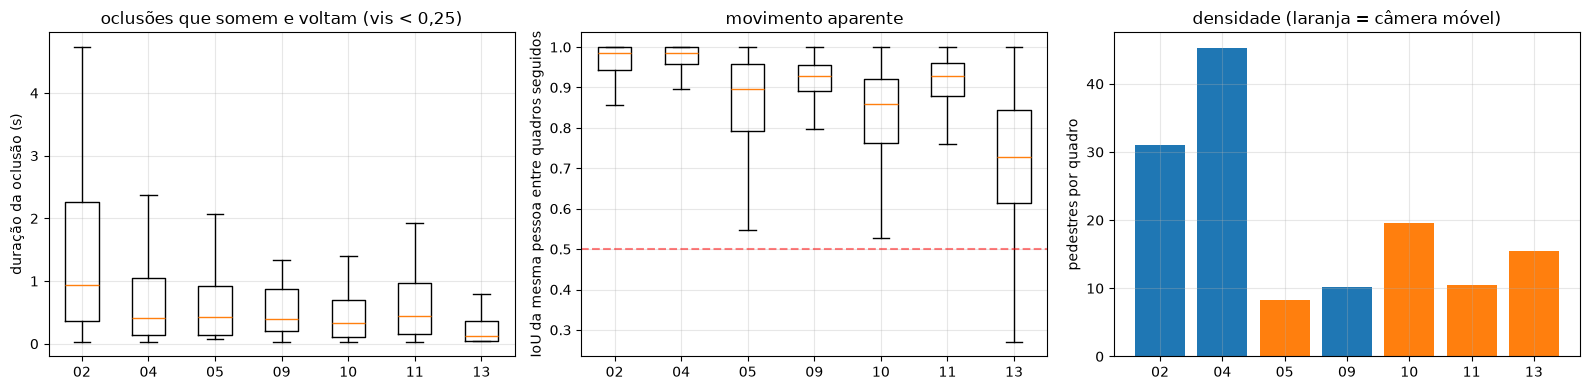

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

names = list(seqs)
occ = {n: occlusion_durations(seqs[n].gt, max_visibility=0.25) / seqs[n].fps for n in names}
cious = {n: consecutive_iou(seqs[n].gt) for n in names}

axes[0].boxplot([occ[n] for n in names], showfliers=False)
axes[0].set_xticks(range(1, len(names) + 1), [n[-2:] for n in names])
axes[0].set_ylabel("duração da oclusão (s)")
axes[0].set_title("oclusões que somem e voltam (vis < 0,25)")

axes[1].boxplot([cious[n] for n in names], showfliers=False)
axes[1].set_xticks(range(1, len(names) + 1), [n[-2:] for n in names])
axes[1].axhline(0.5, color="r", linestyle="--", alpha=0.5)
axes[1].set_ylabel("IoU da mesma pessoa entre quadros seguidos")
axes[1].set_title("movimento aparente")

axes[2].bar([n[-2:] for n in names], stats.loc[names, "density"],
            color=["tab:orange" if stats.loc[n, "camera"] == "movel" else "tab:blue" for n in names])
axes[2].set_ylabel("pedestres por quadro")
axes[2].set_title("densidade (laranja = câmera móvel)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

occlusion_table = pd.concat([pd.DataFrame({"sequence": n, "frames": (occ[n] * seqs[n].fps).round().astype(int),
                                            "seconds": occ[n]}) for n in names])
occlusion_table.to_csv(os.path.join(RESULTS_DIR, "1_gt_occlusion_durations.csv"), index=False)

**O eixo escolhido: movimento aparente** ($1 -$ IoU médio entre quadros seguidos da mesma pessoa). Três motivos, todos decididos *antes* de ver o desempenho do rastreador:

1. é a variável da qual a associação ingênua depende diretamente — o enunciado da Parte 1 é "IoU entre o quadro $t$ e o $t-1$";
2. na Parte 0, o botão que quebrou o baseline mais cedo e mais forte foi a **velocidade**; este é o análogo dela no MOT17, na unidade que o rastreador enxerga (deslocamento relativo ao tamanho da caixa, por quadro — o que também incorpora a taxa de quadros, 14 fps no MOT17-05);
3. ele separa as câmeras móveis das paradas sem precisar de um rótulo categórico.

Densidade e duração de oclusão continuam na análise (seção 7) como eixos alternativos, com a correlação de cada um com as métricas.

## 3. Fonte 1 — as detecções públicas: qual detector?

O MOT17 fornece, para cada sequência, as saídas de três detectores: **DPM** (deformable parts, pré-deep learning), **FRCNN** (Faster R-CNN) e **SDP** (scale-dependent pooling). As caixas já vêm sem sobreposição (nenhum par com IoU > 0,5 no mesmo quadro — já passaram por NMS), mas os scores têm escalas diferentes: o DPM vai de −0,5 a ~5, e FRCNN/SDP saturam em 1,0.

Primeiro a qualidade **por quadro** de cada um, sobre todas as detecções (sem limiar de score):

detector    DPM  FRCNN    SDP
sequence                     
MOT17-02  0.238  0.352  0.475
MOT17-04  0.451  0.552  0.757
MOT17-05  0.409  0.533  0.646
MOT17-09  0.599  0.568  0.650
MOT17-10  0.410  0.598  0.733
MOT17-11  0.558  0.606  0.740
MOT17-13  0.240  0.582  0.554

média no TREINO:
          AP@0.50  mAP@[.50:.95]  recall@0.5  precision@0.5  score=1.0 (%)
detector                                                                  
DPM         0.379          0.191       0.404          0.649         27.348
FRCNN       0.525          0.389       0.527          0.933         71.611
SDP         0.635          0.417       0.641          0.937         62.196


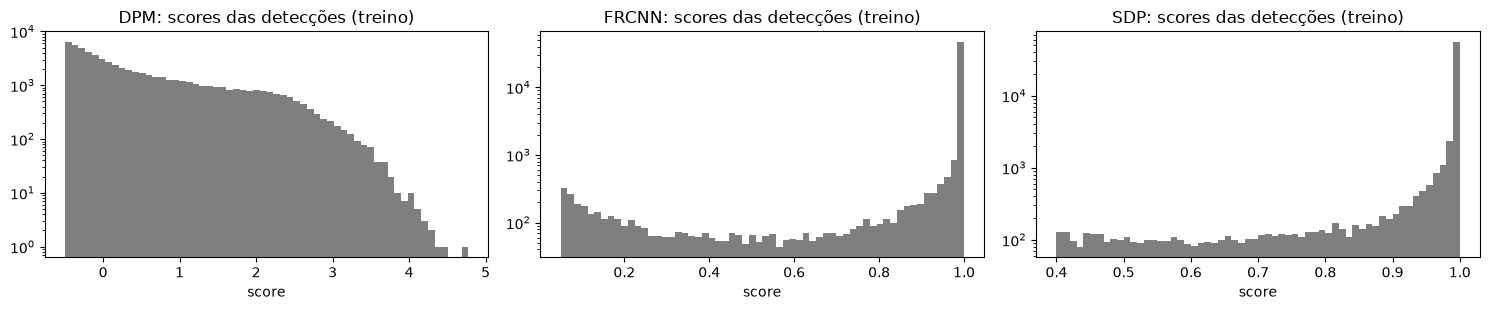

In [5]:
PUBLIC = ["DPM", "FRCNN", "SDP"]

rows = []
for name, s in seqs.items():
    for d in PUBLIC:
        det = remove_distractor_matches(s.public_detections(d), s.gt_all)
        map_value, aps = mean_average_precision(det, s.gt)
        tp, fp, fn = detection_counts(det, s.gt, 0.5)
        rows.append({"sequence": name, "split": split_of(name), "detector": d, "n_det": len(det),
                     "AP@0.50": aps[0.5], "mAP@[.50:.95]": map_value,
                     "recall@0.5": tp / (tp + fn), "precision@0.5": tp / (tp + fp),
                     "score=1.0 (%)": 100 * np.mean(det[:, CONF] >= 0.999)})

public_quality = pd.DataFrame(rows)

print(public_quality.pivot(index="sequence", columns="detector", values="AP@0.50").round(3).to_string())
print("\nmédia no TREINO:")
print(public_quality[public_quality.split == "treino"].groupby("detector")
      [["AP@0.50", "mAP@[.50:.95]", "recall@0.5", "precision@0.5", "score=1.0 (%)"]].mean().round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, d in zip(axes, PUBLIC):
    scores = np.concatenate([seqs[n].public_detections(d)[:, CONF] for n in TRAIN])
    ax.hist(scores, bins=60, color="tab:gray")
    ax.set_title(f"{d}: scores das detecções (treino)")
    ax.set_yscale("log")
    ax.set_xlabel("score")
plt.tight_layout()
plt.show()

O que importa para o PA, porém, não é a detecção por quadro: é o que sobra de identidade depois da associação. Para cada detector, varremos o limiar de score (as escalas não são comparáveis, então cada um tem a sua grade) com a associação ingênua na configuração da Parte 0 (`iou_threshold = 0.3`, `max_age = 5`, guloso) — **só nas sequências de treino**:

In [6]:
DEFAULT_TRACKER = dict(iou_threshold=0.3, max_age=5, matching="greedy")

SCORE_GRID = {
    "DPM":   [-0.5, 0.0, 0.5, 1.0],
    "FRCNN": [0.0, 0.5, 0.9, 0.99],
    "SDP":   [0.4, 0.6, 0.9, 0.99],
}

rows = []
for d, thresholds in SCORE_GRID.items():
    for th in thresholds:
        for name in TRAIN:
            s = seqs[name]
            pred = track_sequence(s.public_detections(d, min_score=th), s.n_frames, **DEFAULT_TRACKER)
            r = evaluate_sequence(pred, s, detection_map=False)
            rows.append({"detector": d, "min_score": th, "sequence": name, **r})

score_sweep = pd.DataFrame(rows)

score_summary = score_sweep.groupby(["detector", "min_score"]).agg(
    IDF1=("IDF1", "mean"), MOTA=("MOTA", "mean"), IDSW=("IDSW", "sum"), FRAG=("FRAG", "sum"),
    id_ratio=("id_ratio", "mean"), FP=("FP", "sum"), FN=("FN", "sum"))
print("média (IDF1, MOTA, id_ratio) e soma (IDSW, FRAG, FP, FN) nas 5 sequências de treino:\n")
show_table(score_summary)

best = score_summary["IDF1"].idxmax()
DET_SOURCE, MIN_SCORE = str(best[0]), float(best[1])
print(f"\nfonte padrão escolhida: {DET_SOURCE} com score >= {MIN_SCORE}  (IDF1 médio no treino = {score_summary.loc[best, 'IDF1']:.3f})")

média (IDF1, MOTA, id_ratio) e soma (IDSW, FRAG, FP, FN) nas 5 sequências de treino:

                    IDF1  MOTA  IDSW  FRAG  id_ratio     FP     FN
detector min_score                                                
DPM      -0.50     0.282 0.155  1808  2599    12.411  23572  54975
          0.00     0.283 0.266  1142  2123     4.498   5048  61940
          0.50     0.259 0.235   753  1657     2.436    890  69668
          1.00     0.209 0.177   528  1445     1.677    107  76750
FRCNN     0.00     0.480 0.464  1228   960     2.822   2535  45051
          0.50     0.490 0.471   981   722     2.146   1133  46541
          0.90     0.496 0.470   720   556     1.738    326  47899
          0.99     0.488 0.443   551   510     1.525     26  50360
SDP       0.40     0.538 0.573  1674  2379     3.967   2569  30984
          0.60     0.546 0.577  1493  2307     3.495   1802  32127
          0.90     0.556 0.567  1145  2243     2.698    908  34711
          0.99     0.509 0.511  1039  2538 

## 4. A associação ingênua: a regra, e quanto os números dependem dela

**Regra de associação** (`src/nn/tracking.py::Tracker` com `StaticMotion`), a cada quadro $t$:

1. **filtro** — detecções com score abaixo do limiar escolhido na seção 3 não entram;
2. **previsão** — a caixa "prevista" de cada track viva é a **última caixa observada** (sem modelo de movimento: para uma track observada em $t-1$ é exatamente a detecção de $t-1$, como pede o enunciado);
3. **custo** — matriz de IoU (tracks vivas × detecções do quadro);
4. **matching** — guloso por IoU decrescente (o par de maior IoU primeiro, cada track e cada detecção no máximo uma vez) ou Hungarian (máxima soma de IoU); pares com IoU < `iou_threshold` são proibidos.

**Gestão de tracks:**

- **nascimento** — toda detecção sem par vira uma track nova, com um id nunca usado antes (ids não são reaproveitados); a track aparece na saída já no quadro em que nasce;
- **coasting** — uma track sem par não emite caixa, só envelhece; se casar de novo antes de morrer, mantém o id;
- **morte** — com mais de `max_age` quadros consecutivos sem observação, a track é descartada; se a pessoa voltar depois disso, ganha id novo.

Os três botões da regra — limiar de IoU, `max_age` e o tipo de matching — numa grade, com a fonte escolhida e só no treino. Como no PA1, regras diferentes dão números diferentes; a grade mostra **quanto**.

In [7]:
IOU_GRID = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
AGE_GRID = [0, 1, 2, 5, 10, 20, 30, 60]
MATCHING = ["greedy", "hungarian"]

source_det = {n: seqs[n].public_detections(DET_SOURCE, min_score=MIN_SCORE) for n in SEQUENCES}

t0 = time.time()
rows = []
for matching in MATCHING:
    for iou_th in IOU_GRID:
        for age in AGE_GRID:
            for name in TRAIN:
                s = seqs[name]
                pred = track_sequence(source_det[name], s.n_frames, iou_threshold=iou_th, max_age=age, matching=matching)
                r = evaluate_sequence(pred, s, detection_map=False)
                rows.append({"matching": matching, "iou_threshold": iou_th, "max_age": age, "sequence": name, **r})

tracker_grid = pd.DataFrame(rows)
tracker_grid.to_csv(os.path.join(RESULTS_DIR, "1_tracker_grid.csv"), index=False)
print(f"{len(tracker_grid)} rodadas em {time.time() - t0:.0f} s")

grid_mean = tracker_grid.groupby(["matching", "iou_threshold", "max_age"])[["IDF1", "MOTA", "IDSW_per_gt_id", "id_ratio", "FRAG"]].mean()

best_cfg = grid_mean["IDF1"].idxmax()
TRACKER_CFG = dict(matching=str(best_cfg[0]), iou_threshold=float(best_cfg[1]), max_age=int(best_cfg[2]))

print(f"melhor regra no treino: {TRACKER_CFG}  ->  IDF1 médio = {grid_mean.loc[best_cfg, 'IDF1']:.3f}")
print(f"faixa de IDF1 médio na grade: {grid_mean['IDF1'].min():.3f} – {grid_mean['IDF1'].max():.3f}")
print(f"configuração da Parte 0 (0.3, 5, guloso): IDF1 médio = {grid_mean.loc[('greedy', 0.3, 5), 'IDF1']:.3f}")

560 rodadas em 649 s
melhor regra no treino: {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 20}  ->  IDF1 médio = 0.576
faixa de IDF1 médio na grade: 0.227 – 0.576
configuração da Parte 0 (0.3, 5, guloso): IDF1 médio = 0.556


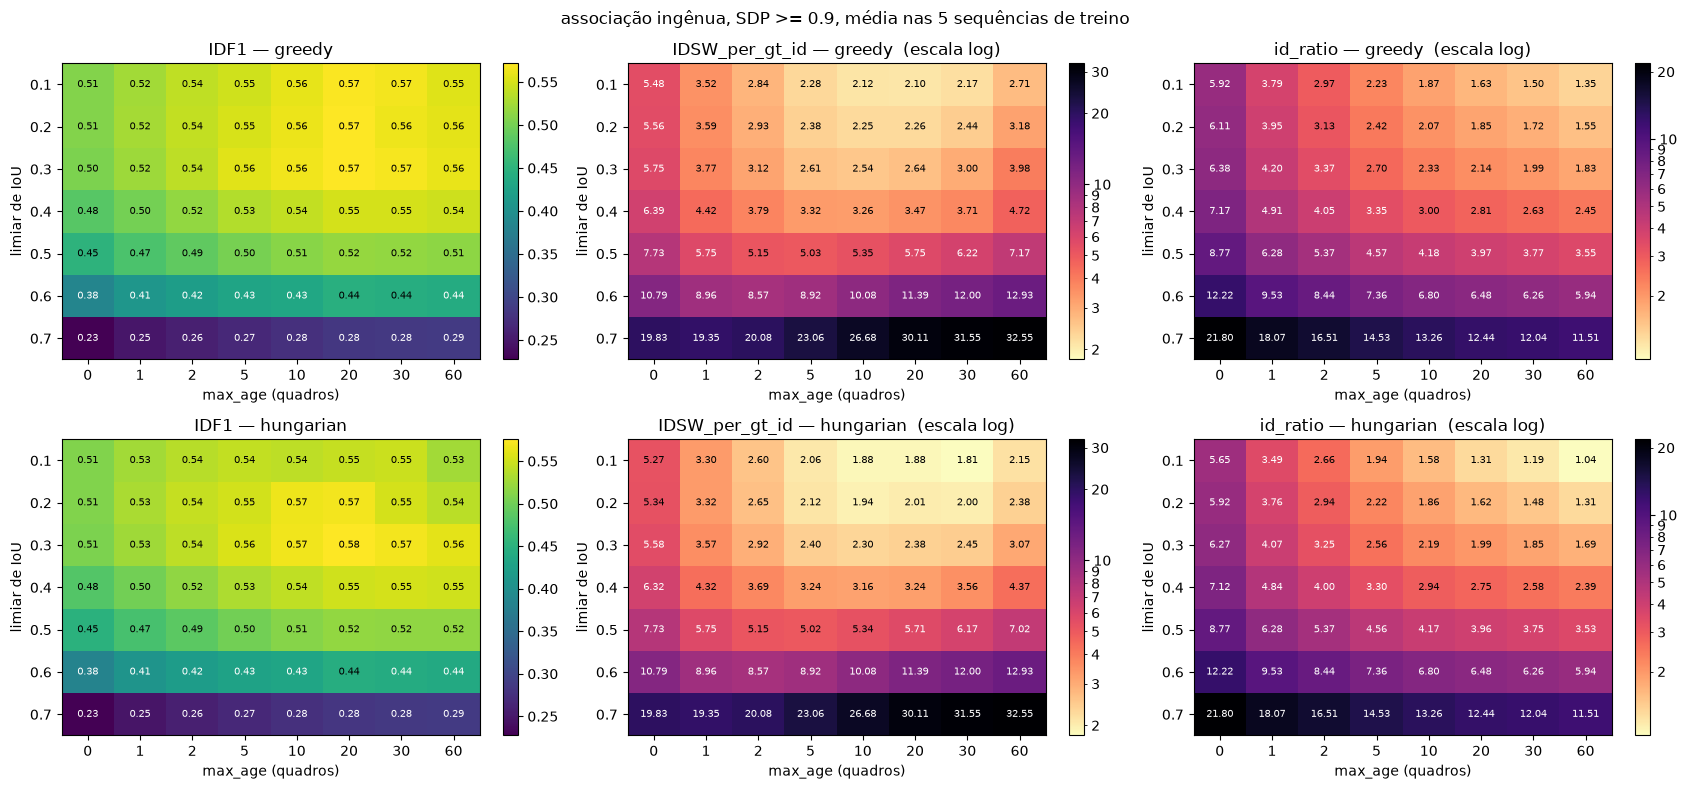

In [8]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for row, matching in enumerate(MATCHING):
    for ax, metric, cmap, log in zip(axes[row], ["IDF1", "IDSW_per_gt_id", "id_ratio"],
                                     ["viridis", "magma_r", "magma_r"], [False, True, True]):
        table = grid_mean.loc[matching][metric].unstack("max_age")
        norm = LogNorm(grid_mean[metric].min(), grid_mean[metric].max()) if log else None
        im = ax.imshow(table.values, cmap=cmap, aspect="auto", norm=norm)
        ax.set_xticks(range(len(table.columns)), table.columns)
        ax.set_yticks(range(len(table.index)), table.index)
        ax.set_xlabel("max_age (quadros)")
        ax.set_ylabel("limiar de IoU")
        ax.set_title(f"{metric} — {matching}" + ("  (escala log)" if log else ""))
        for i in range(table.shape[0]):
            for j in range(table.shape[1]):
                r, g, b, _ = im.cmap(im.norm(table.values[i, j]))
                ax.text(j, i, f"{table.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if 0.299 * r + 0.587 * g + 0.114 * b > 0.5 else "white")
        cb = plt.colorbar(im, ax=ax, fraction=0.046)
        if log:
            cb.ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))
            cb.ax.yaxis.set_minor_formatter(FormatStrFormatter("%g"))

fig.suptitle(f"associação ingênua, {DET_SOURCE} >= {MIN_SCORE}, média nas 5 sequências de treino")
plt.tight_layout()
plt.show()

           matching  iou_threshold  max_age   IDF1  IDF1 com a regra escolhida  câmera
sequence                                                                              
MOT17-02  hungarian            0.3       60  0.439                       0.426  parada
MOT17-04     greedy            0.1       60  0.720                       0.691  parada
MOT17-05     greedy            0.3       10  0.633                       0.616   movel
MOT17-11     greedy            0.2       60  0.647                       0.640   movel
MOT17-13  hungarian            0.1        5  0.573                       0.505   movel


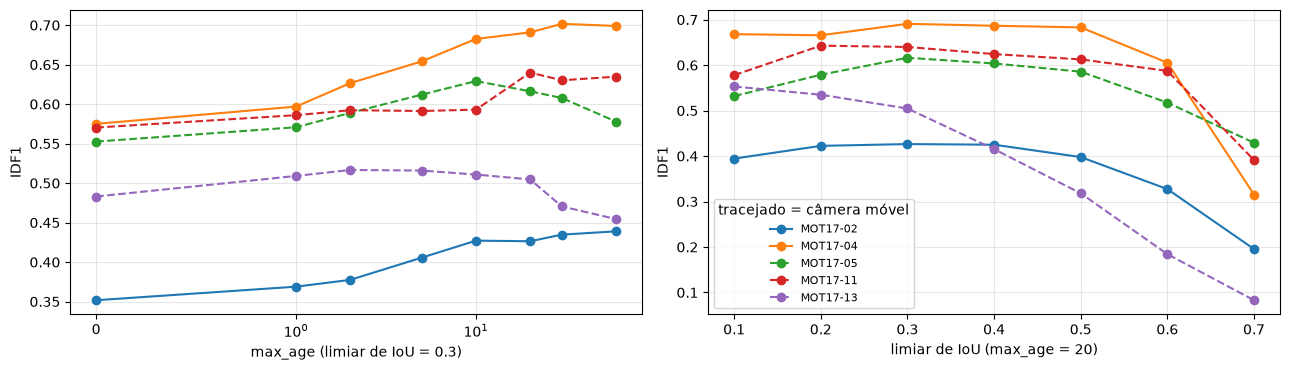

In [9]:
# O que cada sequência prefere: a melhor regra muda com o tipo de câmera?
per_seq_best = (tracker_grid.loc[tracker_grid.groupby("sequence")["IDF1"].idxmax(),
                                 ["sequence", "matching", "iou_threshold", "max_age", "IDF1"]]
                .set_index("sequence"))
per_seq_best["IDF1 com a regra escolhida"] = [
    tracker_grid[(tracker_grid.sequence == n) & (tracker_grid.matching == TRACKER_CFG["matching"])
                 & (tracker_grid.iou_threshold == TRACKER_CFG["iou_threshold"])
                 & (tracker_grid.max_age == TRACKER_CFG["max_age"])]["IDF1"].iloc[0]
    for n in per_seq_best.index]
per_seq_best["câmera"] = [seqs[n].meta["camera"] for n in per_seq_best.index]
print(per_seq_best.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for name in TRAIN:
    part = tracker_grid[(tracker_grid.sequence == name) & (tracker_grid.matching == TRACKER_CFG["matching"])
                        & (tracker_grid.iou_threshold == TRACKER_CFG["iou_threshold"])]
    ls = "--" if seqs[name].meta["camera"] == "movel" else "-"
    axes[0].plot(part["max_age"], part["IDF1"], ls, marker="o", label=name)
    part = tracker_grid[(tracker_grid.sequence == name) & (tracker_grid.matching == TRACKER_CFG["matching"])
                        & (tracker_grid.max_age == TRACKER_CFG["max_age"])]
    axes[1].plot(part["iou_threshold"], part["IDF1"], ls, marker="o", label=name)

axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_xlabel(f"max_age (limiar de IoU = {TRACKER_CFG['iou_threshold']})")
axes[1].set_xlabel(f"limiar de IoU (max_age = {TRACKER_CFG['max_age']})")
for ax in axes:
    ax.set_ylabel("IDF1")
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8, title="tracejado = câmera móvel")
plt.tight_layout()
plt.show()

## 5. Avaliação como trajetórias — fonte padrão, regra escolhida, todas as sequências

A partir daqui a regra fica congelada. A tabela tem todas as métricas pedidas, por sequência (IDF1 com a atribuição global um-para-um; ID switches e fragmentações contados explicitamente; erro de contagem de identidades únicas), e o **mAP por quadro das mesmas caixas** que entraram no IDF1 — com `min_hits = 1` toda detecção acima do limiar sai do rastreador (casada ou como nascimento), então a saída do rastreador e a entrada são o mesmo conjunto de caixas, só que com ids.

A linha "combinado" soma IDTP/IDFP/IDFN e os contadores sobre as sequências (como o MOTChallenge agrega); "média" é a média simples por sequência.

In [10]:
METRIC_COLS = ["IDF1", "IDP", "IDR", "IDSW", "FRAG", "IDSW_per_gt_id", "n_gt_ids", "n_pred_ids",
               "count_error", "id_ratio", "MOTA", "mAP", "AP@0.50"]


def evaluate_source(detections, source_name, cfg):
    rows, tracks = [], {}
    for name, s in seqs.items():
        pred = track_sequence(detections[name], s.n_frames, **cfg)
        tracks[name] = pred
        r = evaluate_sequence(pred, s, detection_map=True)
        rows.append({"sequence": name, "split": split_of(name), "source": source_name, **r})
    return pd.DataFrame(rows), tracks


def with_totals(df):
    out = df.set_index("sequence")[["split"] + METRIC_COLS + ["IDTP", "IDFP", "IDFN", "TP", "FP", "FN"]].copy()
    for label, part in [("combinado (treino)", df[df.split == "treino"]),
                        ("combinado (val)", df[df.split == "val"]),
                        ("combinado (todas)", df)]:
        idtp, idfp, idfn = part["IDTP"].sum(), part["IDFP"].sum(), part["IDFN"].sum()
        n_gt_ids, n_pred_ids = part["n_gt_ids"].sum(), part["n_pred_ids"].sum()
        out.loc[label] = {
            "split": "-", "IDF1": 2 * idtp / (2 * idtp + idfp + idfn), "IDP": idtp / (idtp + idfp),
            "IDR": idtp / (idtp + idfn), "IDSW": part["IDSW"].sum(), "FRAG": part["FRAG"].sum(),
            "IDSW_per_gt_id": part["IDSW"].sum() / n_gt_ids, "n_gt_ids": n_gt_ids, "n_pred_ids": n_pred_ids,
            "count_error": abs(n_pred_ids - n_gt_ids), "id_ratio": n_pred_ids / n_gt_ids,
            "MOTA": 1 - (part["FN"].sum() + part["FP"].sum() + part["IDSW"].sum()) / (part["TP"].sum() + part["FN"].sum()),
            "mAP": part["mAP"].mean(), "AP@0.50": part["AP@0.50"].mean(),
            "IDTP": idtp, "IDFP": idfp, "IDFN": idfn,
            "TP": part["TP"].sum(), "FP": part["FP"].sum(), "FN": part["FN"].sum(),
        }
    out.loc["média por sequência"] = df[METRIC_COLS].mean()
    out.loc["média por sequência", "split"] = "-"
    return out


PUBLIC_NAME = f"{DET_SOURCE} público"
results_public, tracks_public = evaluate_source(source_det, PUBLIC_NAME, TRACKER_CFG)

print(f"fonte: {DET_SOURCE} >= {MIN_SCORE} | regra: {TRACKER_CFG}\n")
show_table(with_totals(results_public), ["split"] + METRIC_COLS)

fonte: SDP >= 0.9 | regra: {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 20}

                      split  IDF1   IDP   IDR   IDSW   FRAG  IDSW_per_gt_id n_gt_ids n_pred_ids count_error  id_ratio  MOTA   mAP  AP@0.50
sequence                                                                                                                                  
MOT17-02             treino 0.426 0.663 0.314    250    703           4.032       62        199         137     3.210 0.422 0.274    0.451
MOT17-04             treino 0.691 0.826 0.594    175    921           2.108       83        110          27     1.325 0.714 0.498    0.718
MOT17-05             treino 0.616 0.814 0.496    135    236           1.015      133        144          11     1.083 0.579 0.424    0.603
MOT17-09                val 0.519 0.670 0.424     66    127           2.538       26         35           9     1.346 0.618 0.455    0.631
MOT17-10                val 0.501 0.600 0.431    327    460           5.737

In [11]:
# As trajetórias das sequências de validação ficam salvas no formato do MOTChallenge,
# para conferir pela linha de comando do entregável:
#   python metrics.py --gt data/MOT17Labels/train/MOT17-09-FRCNN/gt/gt.txt --pred reports/results/1_baseline_tracks/MOT17-09.txt
for name in VAL:
    detections_to_mot(tracks_public[name], os.path.join(RESULTS_DIR, "1_baseline_tracks", f"{name}.txt"))
print(sorted(os.listdir(os.path.join(RESULTS_DIR, "1_baseline_tracks"))))

['MOT17-09.txt', 'MOT17-10.txt']


## 6. Fonte 2 — Faster R-CNN pré-treinado do torchvision

`fasterrcnn_resnet50_fpn_v2` com os pesos do COCO (`src/nn/detector.py`), em modo de inferência, classe *person*. Sem fine-tune.

**Propostas.** 300 por imagem no teste (o padrão do torchvision é 1.000), como no artigo original do Faster R-CNN (Ren et al., 2015). A cabeça do v2 aplica 4 convoluções a cada proposta e custa mais que o backbone; com 300 o custo cai ~30 % e, no quadro mais denso do MOT17-04 (45 pessoas), as detecções finais são as mesmas.

**O NMS é nosso.** O Faster R-CNN do torchvision aplica NMS em dois lugares: dentro da RPN, para reduzir as propostas — parte da arquitetura do detector, que o enunciado permite usar —, e no final, sobre as detecções de cada classe. O NMS **final** foi desligado (`roi_heads.nms_thresh = 1.0`: o NMS do torchvision só suprime caixas com IoU > limiar, e IoU ≤ 1) e substituído por `src/nn/boxes.py::nms`, aplicado sobre as caixas cruas (score ≥ 0,05) que ficam em cache por sequência. Rodar o detector nas 5.316 imagens em CPU leva horas; se o cache não existir, a célula abaixo roda o detector (ou use `python -m src.nn.detector`).

In [12]:
TV_ARCH = DEFAULT_ARCH
TV_NAME = "Faster R-CNN torchvision"

raw_tv = {}
for name, s in seqs.items():
    if not os.path.exists(cache_path(name, TV_ARCH, CACHE_DIR)):
        print(f"{name}: sem cache — rodando o detector ({s.n_frames} quadros)...")
    raw_tv[name] = run_on_sequence(s, arch=TV_ARCH, device=device, cache_dir=CACHE_DIR, verbose=False)

tv_timing = pd.DataFrame([{
    "sequence": name,
    "caixas cruas / quadro": len(raw_tv[name]) / seqs[name].n_frames,
    "s / quadro (CPU)": read_time(name, TV_ARCH, CACHE_DIR),
} for name in SEQUENCES]).set_index("sequence")
print(tv_timing.round(2).to_string())
print("\n(tempo medido com dois processos de 4 threads em paralelo num Ryzen 7 5700U; ~3 s/quadro com um processo de 16 threads)")

MOT17-02: sem cache — rodando o detector (600 quadros)...


KeyboardInterrupt: 

In [ ]:
# Antes / depois do nosso NMS num quadro do MOT17-09
name, t = "MOT17-09", 100
raw_frame = raw_tv[name][raw_tv[name][:, FRAME] == t]
kept_frame = apply_nms(raw_frame, iou_threshold=0.5, min_score=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, rows, title in [(axes[0], raw_frame[raw_frame[:, CONF] >= 0.5], "cru (sem NMS), score >= 0,5"),
                        (axes[1], kept_frame, "depois do nosso NMS (IoU 0,5)")]:
    ax.imshow(seqs[name].image(t))
    for r in rows:
        ax.add_patch(plt.Rectangle((r[X1], r[Y1]), r[X2] - r[X1], r[Y2] - r[Y1], fill=False,
                                   edgecolor="lime", linewidth=0.8))
    ax.set_title(f"{name}, t = {t}: {title} — {len(rows)} caixas")
    ax.axis("off")
plt.tight_layout()
plt.show()

O limiar do nosso NMS e o limiar de score são escolhidos como os da fonte pública: no treino, com a **mesma regra de associação** da seção 4 — a fonte muda, a regra não, para que a comparação seja só da fonte.

In [ ]:
NMS_GRID = [0.4, 0.5, 0.6, 0.7]
TV_SCORE_GRID = [0.3, 0.5, 0.7, 0.9]

rows = []
for nms_th in NMS_GRID:
    nmsed = {n: apply_nms(raw_tv[n], iou_threshold=nms_th, min_score=min(TV_SCORE_GRID)) for n in TRAIN}
    for sc in TV_SCORE_GRID:
        for name in TRAIN:
            det = nmsed[name][nmsed[name][:, CONF] >= sc]
            pred = track_sequence(det, seqs[name].n_frames, **TRACKER_CFG)
            r = evaluate_sequence(pred, seqs[name], detection_map=False)
            rows.append({"nms": nms_th, "min_score": sc, "sequence": name, **r})

tv_sweep = pd.DataFrame(rows)
tv_summary = tv_sweep.groupby(["nms", "min_score"])[["IDF1", "MOTA", "IDSW_per_gt_id", "id_ratio"]].mean()
print(tv_summary["IDF1"].unstack("min_score").round(3).to_string())

TV_NMS, TV_MIN_SCORE = (float(v) for v in tv_summary["IDF1"].idxmax())
print(f"\nescolhido no treino: NMS {TV_NMS}, score >= {TV_MIN_SCORE}  (IDF1 médio = {tv_summary['IDF1'].max():.3f})")

tv_det = {n: apply_nms(raw_tv[n], iou_threshold=TV_NMS, min_score=TV_MIN_SCORE) for n in SEQUENCES}
results_tv, tracks_tv = evaluate_source(tv_det, TV_NAME, TRACKER_CFG)
print(f"\n{TV_NAME} (NMS {TV_NMS}, score >= {TV_MIN_SCORE}) | regra: {TRACKER_CFG}\n")
show_table(with_totals(results_tv), ["split"] + METRIC_COLS)

In [ ]:
# As duas fontes lado a lado. "mAP (todas)" = qualidade do detector como ranking, sem limiar de score;
# "mAP" = das caixas que entraram no rastreador (o que o gráfico do descolamento usa).
full_quality = {}
for name, s in seqs.items():
    full_quality[(PUBLIC_NAME, name)] = mean_average_precision(
        remove_distractor_matches(s.public_detections(DET_SOURCE), s.gt_all), s.gt)[0]
    full_quality[(TV_NAME, name)] = mean_average_precision(
        remove_distractor_matches(apply_nms(raw_tv[name], TV_NMS, 0.05), s.gt_all), s.gt)[0]

results = pd.concat([results_public, results_tv], ignore_index=True)
results["mAP (todas)"] = [full_quality[(src, n)] for src, n in zip(results["source"], results["sequence"])]

comparison = results.pivot(index="sequence", columns="source",
                           values=["mAP (todas)", "mAP", "IDF1", "IDSW_per_gt_id", "id_ratio", "MOTA"])
print(comparison.round(3).to_string())

totals = pd.DataFrame({src: with_totals(results[results.source == src]).loc["combinado (todas)", METRIC_COLS]
                       for src in [PUBLIC_NAME, TV_NAME]})
print("\ncombinado nas 7 sequências:")
show_table(totals.T)

## 7. Quantificando o fracasso — o gráfico do descolamento

Os dois painéis do enunciado sobre as mesmas sete sequências, ordenadas pelo movimento aparente (do mais parado ao mais rápido; o valor do eixo vai embaixo do nome). Em cima, a qualidade **por quadro** (mAP das caixas que o rastreador recebeu) e a **identidade no tempo** (IDF1); embaixo, quantas identidades o rastreador inventou por identidade verdadeira e quantos switches cada identidade verdadeira sofreu. Linha cheia = fonte pública, tracejada = torchvision; faixas amarelas = validação.

In [ ]:
order = stats.sort_values("apparent_motion").index.tolist()
axis_values = [f"{stats.loc[n, 'apparent_motion']:.3f}" for n in order]

fig = plot_decoupling(results, order, sources=[PUBLIC_NAME, TV_NAME],
                      axis_label="movimento aparente = 1 - IoU médio entre quadros seguidos",
                      axis_values=axis_values, highlight=VAL,
                      title="Parte 1 — descolamento entre detecção por quadro e identidade no tempo")
fig.savefig(os.path.join(RESULTS_DIR, "1_decoupling.png"), dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# Os outros eixos candidatos: correlação de Spearman (7 pontos -- indicativo, não teste).
AXES = {"movimento aparente": "apparent_motion", "fração c/ IoU < 0,5": "frac_low_iou",
        "densidade": "density", "fração ocluída": "frac_occluded", "oclusão média (s)": "occ_mean_s",
        "altura da caixa (px)": "box_height"}
METRICS = ["mAP", "IDF1", "IDSW_per_gt_id", "id_ratio"]

rows = []
for src in [PUBLIC_NAME, TV_NAME]:
    part = results[results.source == src].set_index("sequence")
    for axis_name, col in AXES.items():
        row = {"fonte": src, "eixo": axis_name}
        for m in METRICS:
            rho, _ = spearmanr(stats.loc[part.index, col], part[m])
            row[m] = rho
        rows.append(row)

correlations = pd.DataFrame(rows).set_index(["fonte", "eixo"])
print("rho de Spearman entre o eixo e a métrica (7 sequências):\n")
print(correlations.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
part = results[results.source == PUBLIC_NAME].set_index("sequence")
for ax, (axis_name, col) in zip(axes, [("movimento aparente", "apparent_motion"), ("oclusão média (s)", "occ_mean_s"),
                                       ("altura mediana da caixa (px)", "box_height")]):
    ax.scatter(stats.loc[part.index, col], part["IDSW_per_gt_id"], color="tab:red")
    for n in part.index:
        ax.annotate(n[-2:], (stats.loc[n, col], part.loc[n, "IDSW_per_gt_id"]), fontsize=9,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(axis_name)
    ax.set_ylabel("ID switches / id verdadeiro")
    ax.grid(alpha=0.3)
fig.suptitle(f"{PUBLIC_NAME}: switches por identidade contra cada eixo")
plt.tight_layout()
plt.show()

## 8. Onde a identidade se perde

O gráfico mostra *que* o baseline quebra; esta seção mostra *como*. Para cada identidade verdadeira, cada vez que ela volta a ser casada depois de um **buraco** de $g$ quadros (presente no GT mas sem par na saída: o detector não a achou, ou a associação não a ligou), registramos se o id previsto é o mesmo de antes (`src/nn/metrics.py::reacquisition_events`). $g = 0$ são quadros seguidos: uma troca ali é um switch entre vizinhos.

Cada evento de perda (id diferente) cai numa de três causas:

- **troca entre vizinhos** ($g = 0$): a track de outra pessoa ficou com a detecção — confusão de associação;
- **perdida no coasting** ($1 \le g \le$ `max_age`): a track ainda estava viva, mas a última caixa observada já não tinha IoU com a pessoa quando ela voltou — falta de modelo de movimento;
- **morta e renascida** ($g >$ `max_age`): a track foi descartada; a volta ganha id novo por construção — falta de memória.

In [ ]:
first_frame = {}
all_events = []
for name in SEQUENCES:
    pred = remove_distractor_matches(tracks_public[name], seqs[name].gt_all)
    first = {int(i): int(pred[pred[:, ID] == i, FRAME].min()) for i in np.unique(pred[:, ID])}
    for e in reacquisition_events(pred, seqs[name].gt):
        e["sequence"] = name
        e["camera"] = seqs[name].meta["camera"]
        e["after_is_new"] = first[e["after"]] == e["frame"]
        all_events.append(e)

events = pd.DataFrame(all_events)
K = TRACKER_CFG["max_age"]

def cause(e):
    if e["kept"]:
        return "mantido"
    if e["gap"] == 0:
        return "troca entre vizinhos (g = 0)"
    if e["gap"] <= K:
        return f"perdida no coasting (1 <= g <= {K})"
    return f"morta e renascida (g > {K})"

events["causa"] = events.apply(cause, axis=1)

losses = events[~events["kept"]]
breakdown = pd.crosstab(losses["sequence"], losses["causa"], margins=True, margins_name="total")
print("eventos de perda de identidade por causa (contagem):\n")
print(breakdown.to_string())
print("\nfração de cada causa, por tipo de câmera:")
print(pd.crosstab(losses["camera"], losses["causa"], normalize="index").round(2).to_string())
print("\nentre as perdas, fração em que o id novo é uma track recém-nascida (e não uma track existente):",
      round(losses["after_is_new"].mean(), 2))

In [ ]:
curves = {
    "câmera parada (02, 04, 09)": keep_rate_by_gap(events[events.camera == "parada"].to_dict("records")),
    "câmera móvel (05, 10, 11, 13)": keep_rate_by_gap(events[events.camera == "movel"].to_dict("records")),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
plot_keep_rate(curves, max_age=K, ax=axes[0],
               title=f"a identidade sobrevive a um buraco de g quadros? ({PUBLIC_NAME})")

gaps = events.loc[events["gap"] > 0, "gap"]
gt_occ = occlusion_table["frames"]
bins = np.unique(np.logspace(0, np.log10(max(gaps.max(), gt_occ.max()) + 1), 25).astype(int))
axes[1].hist(gt_occ, bins=bins, alpha=0.5, density=True, label="oclusões no GT (vis < 0,25, some e volta)")
axes[1].hist(gaps, bins=bins, alpha=0.5, density=True, label="buracos na saída do baseline")
axes[1].axvline(K + 0.5, color="k", linestyle="--", alpha=0.6)
axes[1].text(K + 0.7, axes[1].get_ylim()[1] * 0.85, f"max_age = {K}", fontsize=8)
axes[1].set_xscale("log")
axes[1].set_xlabel("duração (quadros)")
axes[1].set_ylabel("densidade")
axes[1].legend(fontsize=8)
axes[1].set_title("duração dos buracos vs. duração das oclusões do dataset")
plt.tight_layout()
plt.show()

print(f"oclusões do GT mais longas que max_age = {K}: {np.mean(gt_occ > K):.0%}  "
      f"(mediana {np.median(gt_occ):.0f} quadros, p90 {np.percentile(gt_occ, 90):.0f})")

### As sequências de validação de perto

A linha do tempo do MOT17-09 (validação, câmera parada, 26 identidades): uma faixa por identidade verdadeira, cor = id previsto casado naquele quadro, cinza = presente no GT sem par. Trocas de cor dentro de uma faixa são ID switches.

In [ ]:
name = "MOT17-09"
pred = remove_distractor_matches(tracks_public[name], seqs[name].gt_all)
fig = plot_tracks_timeline(pred, seqs[name].gt, title=f"{name} — {PUBLIC_NAME}, regra {TRACKER_CFG}")
plt.show()

Duas perdas típicas no MOT17-10 (validação, câmera móvel), escolhidas por regra — entre as perdas em que a pessoa estava **bem visível** (visibilidade ≥ 0,6) antes e depois do buraco, a de maior caixa em cada causa. Linha cheia: o GT da pessoa; tracejado: a saída do baseline, cor = id previsto.

In [ ]:
def loss_example(name, cause_prefix):
    s = seqs[name]
    vis = {(int(f), int(i)): v for f, i, v in s.gt[:, [FRAME, ID, CONF]]}
    height = {int(i): np.median(s.gt[s.gt[:, ID] == i, Y2] - s.gt[s.gt[:, ID] == i, Y1]) for i in np.unique(s.gt[:, ID])}
    cand = events[(events.sequence == name) & (~events.kept) & events.causa.str.startswith(cause_prefix)].copy()
    cand["t_last"] = cand["frame"] - cand["gap"] - 1
    cand["vis_last"] = [vis.get((t, g), 0.0) for t, g in zip(cand.t_last, cand.gt_id)]
    cand["vis_back"] = [vis.get((t, g), 0.0) for t, g in zip(cand.frame, cand.gt_id)]
    cand["height"] = [height[g] for g in cand.gt_id]
    cand = cand[(cand.vis_last >= 0.6) & (cand.vis_back >= 0.6)]
    return cand.sort_values("height", ascending=False).iloc[0] if len(cand) else None


def show_loss(name, e):
    s = seqs[name]
    gid, t_back, g = int(e["gt_id"]), int(e["frame"]), int(e["gap"])
    t_last = t_back - g - 1
    frames = sorted(set(np.clip([t_last - 2, t_last, t_last + (g + 1) // 2 if g else t_last, t_back, t_back + 2],
                                0, s.n_frames - 1).tolist()))

    subject = s.gt[s.gt[:, ID] == gid]
    box = subject[(subject[:, FRAME] >= frames[0]) & (subject[:, FRAME] <= frames[-1]), X1:Y2 + 1]
    w, h = box[:, 2].max() - box[:, 0].min(), box[:, 3].max() - box[:, 1].min()
    crop = (max(box[:, 0].min() - 1.5 * w, 0), max(box[:, 1].min() - 0.3 * h, 0),
            min(box[:, 2].max() + 1.5 * w, s.width), min(box[:, 3].max() + 0.3 * h, s.height))

    after_kind = "track recém-nascida" if e["after_is_new"] else "track já existente"
    print(f"{name}, GT {gid} — {e['causa']}: casada com o id {int(e['before'])} até t = {t_last}, "
          f"{g} quadro(s) sem par, volta em t = {t_back} com o id {int(e['after'])} ({after_kind}); "
          f"visibilidade {e['vis_last']:.2f} -> {e['vis_back']:.2f}")

    fig = show_sequence_frames(s, frames, gt=subject, pred=tracks_public[name], crop=crop, figsize_per=3.2,
                               title=f"{name}: GT {gid} — {e['causa']}")
    plt.show()


for prefix in ["perdida no coasting", "troca entre vizinhos"]:
    e = loss_example("MOT17-10", prefix)
    if e is not None:
        show_loss("MOT17-10", e)

In [ ]:
# ============================================================
# SALVA OS NÚMEROS DA PARTE 1
# ============================================================
#
# A Parte 2 lê este arquivo para a tabela lado a lado (baseline x memória
# temporal) nas MESMAS sequências, com a MESMA fonte e o mesmo split.

results.to_csv(os.path.join(RESULTS_DIR, "1_baseline_sequences.csv"), index=False)
stats.to_csv(os.path.join(RESULTS_DIR, "1_sequence_statistics.csv"))
events.to_csv(os.path.join(RESULTS_DIR, "1_reacquisition_events.csv"), index=False)

summary = {
    "split": SPLIT,
    "difficulty_axis": "apparent_motion = 1 - IoU médio entre quadros seguidos da mesma pessoa",
    "sequence_order": order,
    "public_source": {"detector": DET_SOURCE, "min_score": float(MIN_SCORE)},
    "torchvision_source": {"arch": TV_ARCH, "nms": float(TV_NMS), "min_score": float(TV_MIN_SCORE)},
    "tracker": TRACKER_CFG,
    "per_sequence": {
        src: results[results.source == src].set_index("sequence")[METRIC_COLS].to_dict(orient="index")
        for src in [PUBLIC_NAME, TV_NAME]
    },
    "combined": {
        src: with_totals(results[results.source == src]).loc[
            ["combinado (treino)", "combinado (val)", "combinado (todas)"], METRIC_COLS].to_dict(orient="index")
        for src in [PUBLIC_NAME, TV_NAME]
    },
    "loss_causes": {k: int(v) for k, v in losses["causa"].value_counts().items()},
    "spearman": correlations.reset_index().to_dict(orient="records"),
}

with open(os.path.join(RESULTS_DIR, "1_baseline.json"), "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2, ensure_ascii=False, default=float)

print(json.dumps({k: summary[k] for k in ["split", "public_source", "torchvision_source", "tracker", "loss_causes"]},
                 indent=2, ensure_ascii=False, default=float))